In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
FILE_PATH = "logistics_analysis_data.csv"
df = pd.read_csv(FILE_PATH)

In [4]:
# Convert the date column and create useful time variables
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").astype(str)
df["cost_per_kg"] = df["transport_cost_usd"] / df["shipment_volume_kg"]
df["is_delayed"] = (df["delay_hours"] > 2).astype(int)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 18)


,shipment_id,date,origin_city,destination_city,carrier,product_category,shipment_volume_kg,distance_km,transport_cost_usd,delivery_time_hours,scheduled_delivery_hours,delay_hours,on_time_delivery,customer_satisfaction,warehouse_id,month,cost_per_kg,is_delayed
0,SHP000001,2026-06-13,Delhi,Mumbai,EcoTrans,FMCG,446.131426,1490.788489,296.720992,33.010977,34.192892,-1.181914,1,5.000000,W004,2026-06,0.665098,0
1,SHP000002,2026-02-05,Delhi,Pune,FastShip,Textiles,325.284175,1445.337898,301.905376,35.489301,40.208519,-4.719217,1,5.000000,W007,2026-02,0.928128,0
2,SHP000003,2026-01-09,Mumbai,Delhi,GlobalLine,FMCG,250.769572,678.060262,180.519005,14.733166,16.674634,-1.941468,1,5.000000,W009,2026-01,0.719860,0
3,SHP000004,2026-06-04,Mumbai,Hyderabad,GlobalLine,Textiles,91.606620,365.038335,71.888282,12.069874,8.833260,3.236614,0,4.563450,W007,2026-06,0.784750,1
4,SHP000005,2026-02-26,Ahmedabad,Kolkata,EcoTrans,Electronics,103.876429,1225.587681,115.923069,20.235380,31.430526,-11.195146,1,4.699873,W003,2026-02,1.115971,0


In [5]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate shipment IDs:", df["shipment_id"].duplicated().sum())

Missing values:
shipment_id                 0
date                        0
origin_city                 0
destination_city            0
carrier                     0
product_category            0
shipment_volume_kg          0
distance_km                 0
transport_cost_usd          0
delivery_time_hours         0
scheduled_delivery_hours    0
delay_hours                 0
on_time_delivery            0
customer_satisfaction       0
warehouse_id                0
month                       0
cost_per_kg                 0
is_delayed                  0
dtype: int64

Duplicate rows: 0
Duplicate shipment IDs: 0


In [6]:
#  Descriptive statistics for numerical variables
numeric_columns = [
    "shipment_volume_kg", "distance_km", "transport_cost_usd",
    "delivery_time_hours", "scheduled_delivery_hours", "delay_hours",
    "customer_satisfaction", "cost_per_kg"
]

summary_stats = df[numeric_columns].describe().T
summary_stats["median"] = df[numeric_columns].median()
summary_stats["variance"] = df[numeric_columns].var()
summary_stats.round(2)


,count,mean,std,min,25%,50%,75%,max,median,variance
shipment_volume_kg,2000.0,418.27,689.88,13.39,73.57,179.61,428.84,6951.92,179.61,475929.73
distance_km,2000.0,1053.57,547.07,100.02,580.17,1038.46,1542.58,1999.16,1038.46,299282.87
transport_cost_usd,2000.0,305.61,360.35,20.82,122.79,190.41,324.74,4199.37,190.41,129851.42
delivery_time_hours,2000.0,26.06,15.41,0.87,13.29,24.23,36.69,85.41,24.23,237.44
scheduled_delivery_hours,2000.0,26.28,13.78,2.29,14.45,25.74,38.03,55.25,25.74,189.82
delay_hours,2000.0,-0.22,7.34,-45.20,-3.86,-0.10,3.32,36.15,-0.10,53.93
customer_satisfaction,2000.0,4.60,0.52,1.00,4.36,4.82,5.00,5.00,4.82,0.28
cost_per_kg,2000.0,1.43,1.29,0.41,0.67,0.94,1.58,12.71,0.94,1.67


In [7]:
# Overall logistics KPIs
kpis = pd.DataFrame({
    "Metric": [
        "Total Shipments",
        "Total Shipment Volume (kg)",
        "Average Transport Cost (USD)",
        "Median Transport Cost (USD)",
        "Average Delivery Time (hours)",
        "Average Delay (hours)",
        "On-Time Delivery Rate (%)",
        "Average Customer Satisfaction (1-5)",
        "Average Cost per kg (USD)"
    ],
    "Value": [
        len(df),
        df["shipment_volume_kg"].sum(),
        df["transport_cost_usd"].mean(),
        df["transport_cost_usd"].median(),
        df["delivery_time_hours"].mean(),
        df["delay_hours"].mean(),
        df["on_time_delivery"].mean() * 100,
        df["customer_satisfaction"].mean(),
        df["cost_per_kg"].mean()
    ]
})
kpis["Value"] = kpis["Value"].map(lambda x: round(x, 2))
kpis

,Metric,Value
0,Total Shipments,2000.00
1,Total Shipment Volume (kg),836536.68
2,Average Transport Cost (USD),305.61
3,Median Transport Cost (USD),190.41
4,Average Delivery Time (hours),26.06
5,Average Delay (hours),-0.22
6,On-Time Delivery Rate (%),67.50
7,Average Customer Satisfaction (1-5),4.60
8,Average Cost per kg (USD),1.43


In [8]:
#  Carrier performance analysis
carrier_summary = df.groupby("carrier").agg(
    shipments=("shipment_id", "count"),
    average_cost_usd=("transport_cost_usd", "mean"),
    average_delivery_hours=("delivery_time_hours", "mean"),
    average_delay_hours=("delay_hours", "mean"),
    on_time_rate_percent=("on_time_delivery", lambda x: x.mean() * 100),
    average_satisfaction=("customer_satisfaction", "mean"),
    average_cost_per_kg=("cost_per_kg", "mean")
).round(2).sort_values("on_time_rate_percent", ascending=False)
carrier_summary

,shipments,average_cost_usd,average_delivery_hours,average_delay_hours,on_time_rate_percent,average_satisfaction,average_cost_per_kg
carrier,,,,,,,
GlobalLine,470,295.61,26.10,-0.33,69.36,4.60,1.35
FastShip,510,339.88,26.07,-0.17,68.24,4.62,1.61
PrimeLogistics,557,329.77,26.56,-0.34,66.79,4.59,1.56
EcoTrans,463,248.94,25.42,-0.02,65.66,4.59,1.14


In [9]:
#  Product-category performance analysis
category_summary = df.groupby("product_category").agg(
    shipments=("shipment_id", "count"),
    average_volume_kg=("shipment_volume_kg", "mean"),
    average_cost_usd=("transport_cost_usd", "mean"),
    average_delay_hours=("delay_hours", "mean"),
    on_time_rate_percent=("on_time_delivery", lambda x: x.mean() * 100),
    average_satisfaction=("customer_satisfaction", "mean")
).round(2).sort_values("on_time_rate_percent", ascending=False)
category_summary

,shipments,average_volume_kg,average_cost_usd,average_delay_hours,on_time_rate_percent,average_satisfaction
product_category,,,,,,
Electronics,408,113.13,147.51,-0.45,69.36,4.61
Automotive,370,1398.59,813.31,-0.35,68.92,4.62
Textiles,396,224.96,206.84,-0.47,67.68,4.62
Pharmaceuticals,408,40.62,107.94,-0.14,66.42,4.59
FMCG,418,400.10,297.04,0.28,65.31,4.56


In [10]:
#  Monthly trend analysis
monthly_summary = df.groupby("month").agg(
    shipments=("shipment_id", "count"),
    total_volume_kg=("shipment_volume_kg", "sum"),
    average_cost_usd=("transport_cost_usd", "mean"),
    average_delivery_hours=("delivery_time_hours", "mean"),
    on_time_rate_percent=("on_time_delivery", lambda x: x.mean() * 100),
    average_satisfaction=("customer_satisfaction", "mean")
).round(2)
monthly_summary

,shipments,total_volume_kg,average_cost_usd,average_delivery_hours,on_time_rate_percent,average_satisfaction
month,,,,,,
2026-01,343,163433.47,328.33,24.00,73.18,4.65
2026-02,299,113461.68,291.16,28.20,63.88,4.55
2026-03,345,151545.83,311.61,25.50,68.12,4.62
2026-04,333,134116.89,296.80,25.52,65.17,4.59
2026-05,332,123864.06,283.38,26.68,68.67,4.60
2026-06,348,150114.74,319.32,26.75,65.52,4.58


# Visualization

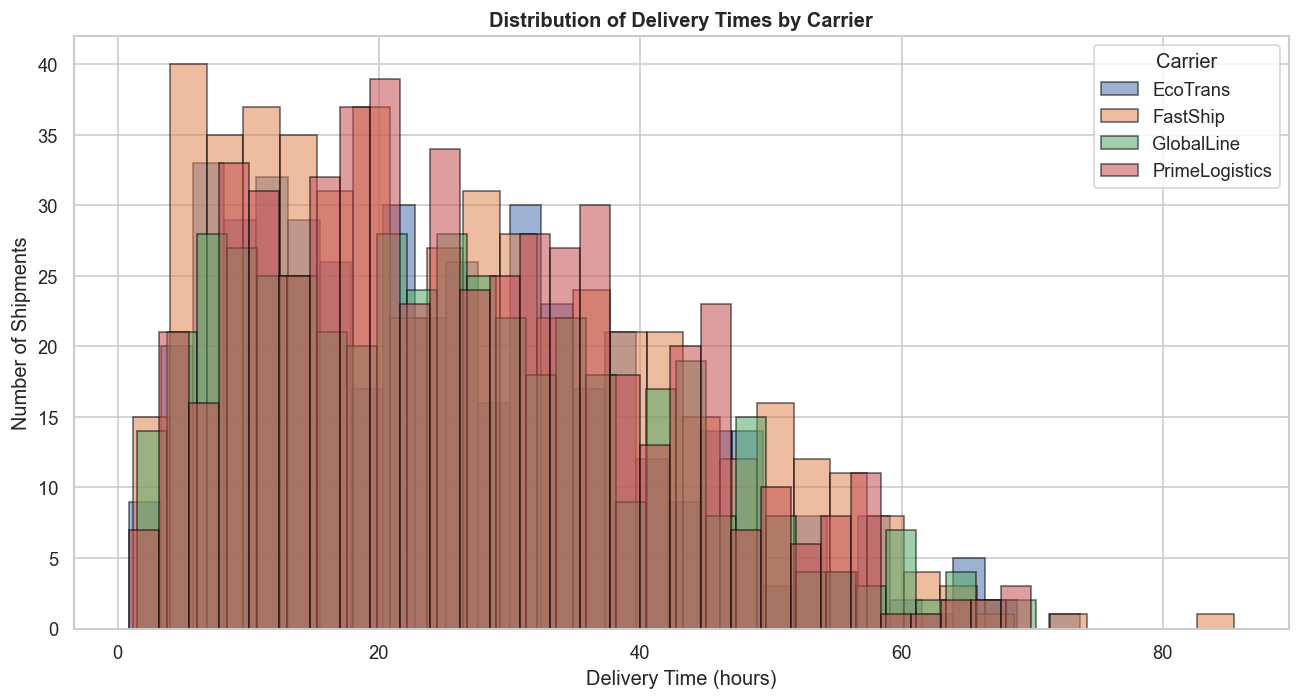

In [11]:
plt.figure(figsize=(11, 6))
for carrier in sorted(df["carrier"].unique()):
    subset = df.loc[df["carrier"] == carrier, "delivery_time_hours"]
    plt.hist(subset, bins=30, alpha=0.55, label=carrier, edgecolor="black")

plt.title("Distribution of Delivery Times by Carrier", weight="bold")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Number of Shipments")
plt.legend(title="Carrier")
plt.tight_layout()
plt.show()

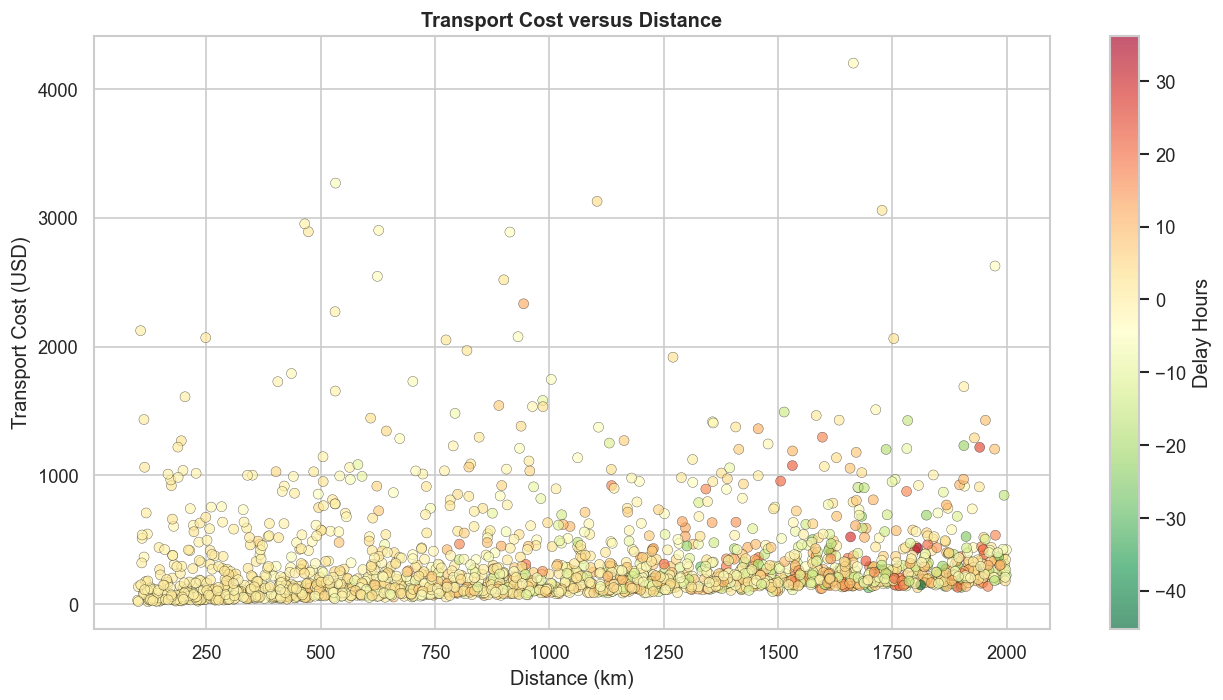

In [12]:
plt.figure(figsize=(11, 6))
scatter = plt.scatter(
    df["distance_km"],
    df["transport_cost_usd"],
    c=df["delay_hours"],
    cmap="RdYlGn_r",
    alpha=0.65,
    edgecolors="black",
    linewidths=0.25
)
plt.colorbar(scatter, label="Delay Hours")
plt.title("Transport Cost versus Distance", weight="bold")
plt.xlabel("Distance (km)")
plt.ylabel("Transport Cost (USD)")
plt.tight_layout()
plt.show()

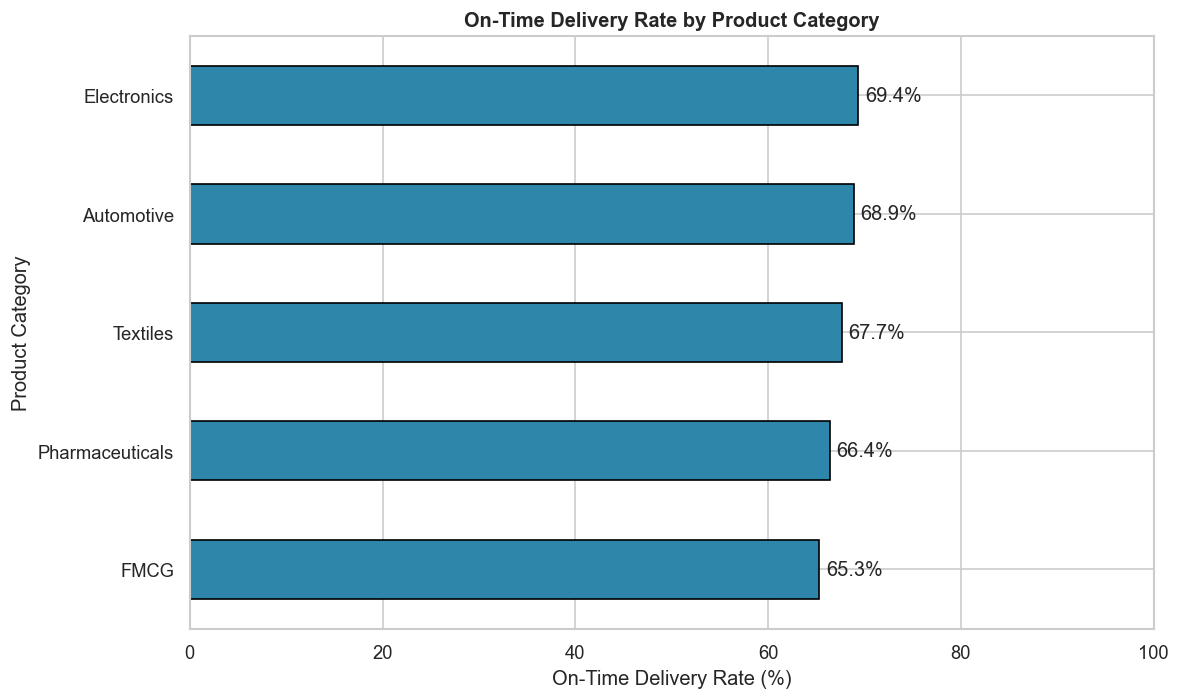

In [13]:
category_rates = (
    df.groupby("product_category")["on_time_delivery"]
    .mean()
    .mul(100)
    .sort_values()
)

ax = category_rates.plot(kind="barh", color="#2E86AB", edgecolor="black", figsize=(10, 6))
plt.title("On-Time Delivery Rate by Product Category", weight="bold")
plt.xlabel("On-Time Delivery Rate (%)")
plt.ylabel("Product Category")
plt.xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4)
plt.tight_layout()
plt.show()

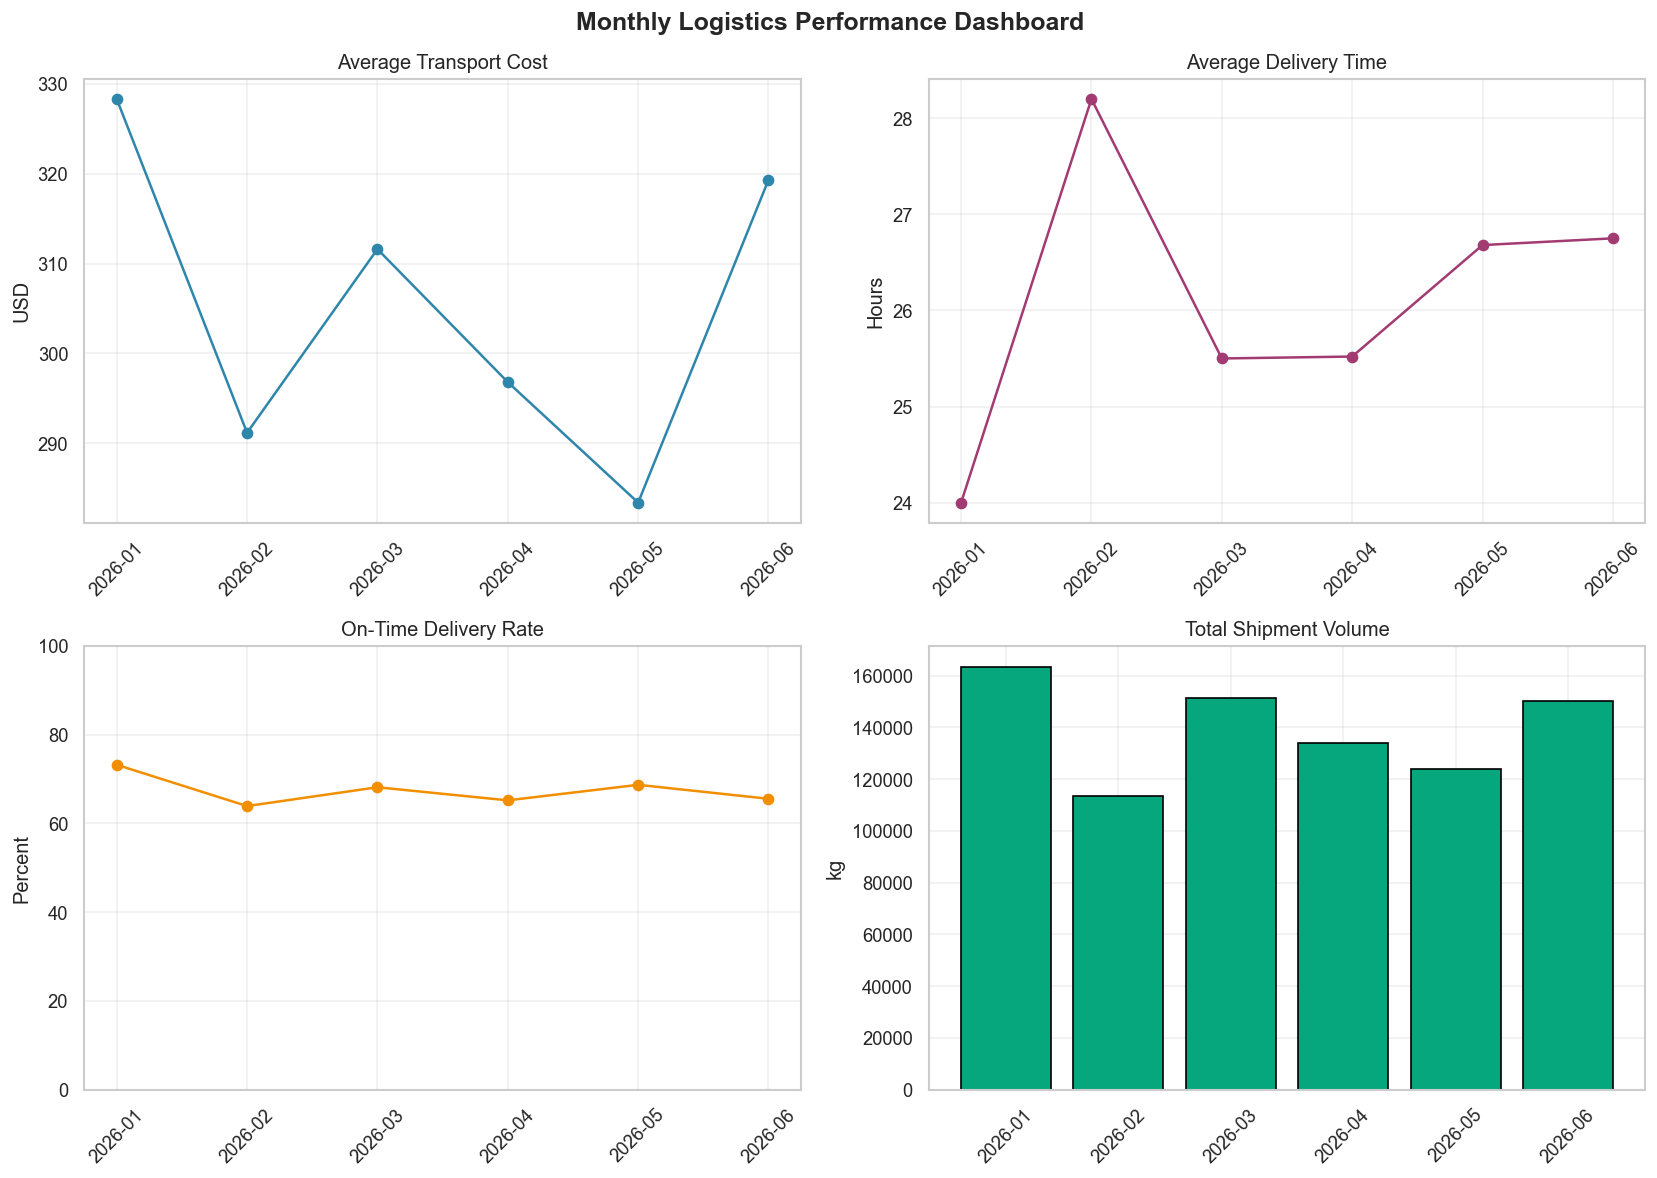

In [14]:
monthly_plot = monthly_summary.reset_index()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(monthly_plot["month"], monthly_plot["average_cost_usd"], marker="o", color="#2E86AB")
axes[0, 0].set_title("Average Transport Cost")
axes[0, 0].set_ylabel("USD")

axes[0, 1].plot(monthly_plot["month"], monthly_plot["average_delivery_hours"], marker="o", color="#A23B72")
axes[0, 1].set_title("Average Delivery Time")
axes[0, 1].set_ylabel("Hours")

axes[1, 0].plot(monthly_plot["month"], monthly_plot["on_time_rate_percent"], marker="o", color="#F18F01")
axes[1, 0].set_title("On-Time Delivery Rate")
axes[1, 0].set_ylabel("Percent")
axes[1, 0].set_ylim(0, 100)

axes[1, 1].bar(monthly_plot["month"], monthly_plot["total_volume_kg"], color="#06A77D", edgecolor="black")
axes[1, 1].set_title("Total Shipment Volume")
axes[1, 1].set_ylabel("kg")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

plt.suptitle("Monthly Logistics Performance Dashboard", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

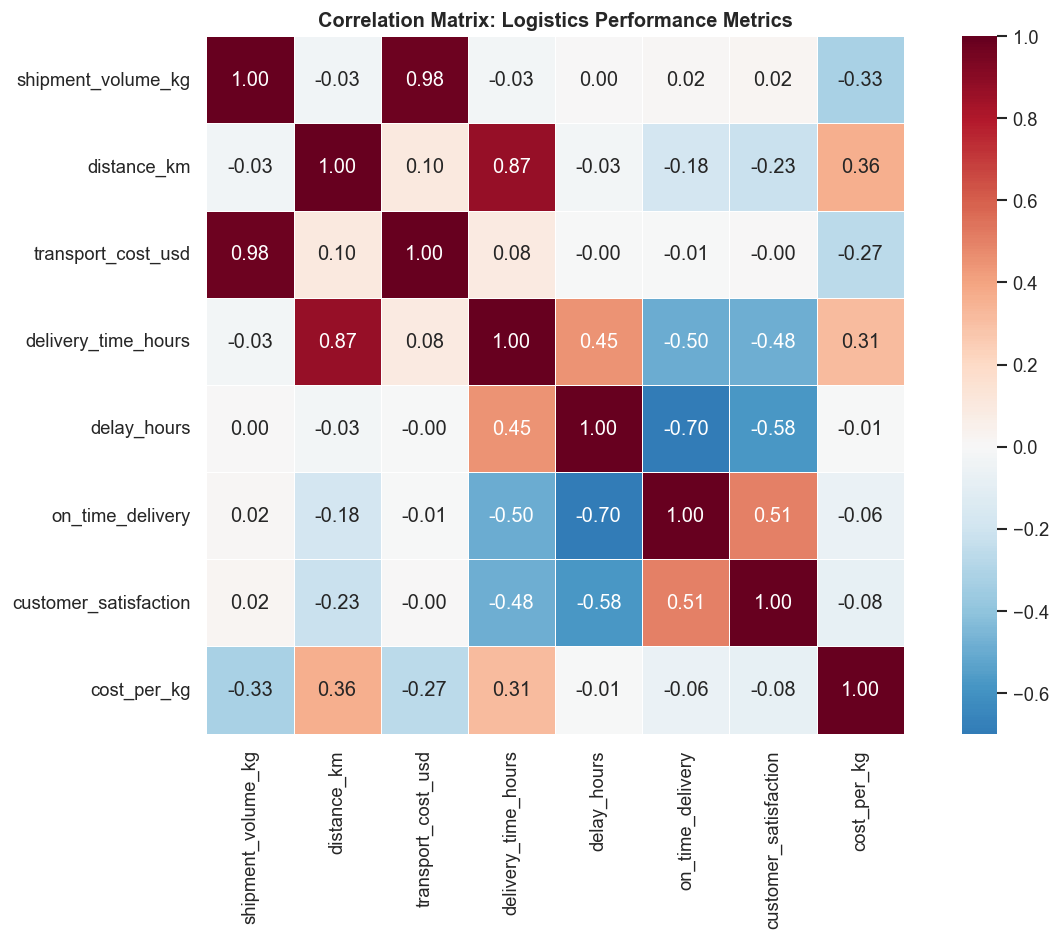

In [15]:
corr_columns = [
    "shipment_volume_kg", "distance_km", "transport_cost_usd",
    "delivery_time_hours", "delay_hours", "on_time_delivery",
    "customer_satisfaction", "cost_per_kg"
]
correlation_matrix = df[corr_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix: Logistics Performance Metrics", weight="bold")
plt.tight_layout()
plt.show()